# 🏥 Healthcare Disease Prediction System (Symptom-Based)
**Author:** Jahangir Amiri
**Course:** Machine Learning — NED University of Engineering & Technology
**Algorithm:** Random Forest Classifier
**Dataset:** Disease Prediction Using Machine Learning (Kaggle — kaushil268)

---
### 📌 Objective
Predict a patient's disease (1 of 41 possible diagnoses) based on which of 132 symptoms they are experiencing, using a Random Forest Classifier trained on real, clinically-grounded symptom-disease mappings.

## Step 1 — Import Libraries

In [1]:
# Standard data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Step 2 — Load & Explore the Dataset

This dataset ships with a pre-made train/test split (`Training.csv` and `Testing.csv`), each row is a patient with 132 binary symptom columns (1 = symptom present, 0 = absent) and a `prognosis` column holding the diagnosed disease.

In [2]:
# Load the dataset
train = pd.read_csv('Training.csv')
test = pd.read_csv('Testing.csv')

print('Training shape:', train.shape)
print('Testing shape:', test.shape)
train.head()

Training shape: (4920, 134)
Testing shape: (42, 133)


   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  muscle_wasting  vomiting  burning_micturition  spotting_ urination  fatigue  weight_gain  anxiety  cold_hands_and_feets  mood_swings  weight_loss  restlessness  lethargy  patches_in_throat  irregular_sugar_level  cough  high_fever  sunken_eyes  breathlessness  sweating  dehydration  indigestion  headache  yellowish_skin  dark_urine  nausea  loss_of_appetite  pain_behind_the_eyes  back_pain  constipation  abdominal_pain  diarrhoea  mild_fever  yellow_urine  yellowing_of_eyes  acute_liver_failure  fluid_overload  swelling_of_stomach  swelled_lymph_nodes  malaise  blurred_and_distorted_vision  phlegm  throat_irritation  redness_of_eyes  sinus_pressure  runny_nose  congestion  chest_pain  weakness_in_limbs  fast_heart_rate  pain_during_bowel_movements  pain_in_anal_region  bloody_stool  irritation_in_anus  neck_pain  dizziness  cramps  bruising  obesity 

In [3]:
# Check data types and missing values
print('Missing values in training set:', train.isnull().sum().sum())
print('Missing values in testing set:', test.isnull().sum().sum())
print('\nNumber of disease classes:', train['prognosis'].nunique())

Missing values in training set: 4920
Missing values in testing set: 0

Number of disease classes: 41


In [4]:
# How many samples per class in training data?
train['prognosis'].value_counts()

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

## Step 3 — Data Preprocessing

In [5]:
# The exported CSV has a trailing empty column + a trailing comma artifact — drop it
train = train.loc[:, ~train.columns.str.contains('Unnamed')]
test = test.loc[:, ~test.columns.str.contains('Unnamed')]

# Strip whitespace from the target labels (e.g. ' Diabetes ' -> 'Diabetes')
train['prognosis'] = train['prognosis'].str.strip()
test['prognosis'] = test['prognosis'].str.strip()

print(f'✅ Remaining columns: {train.shape[1]} (132 symptoms + 1 target)')

✅ Remaining columns: 133 (132 symptoms + 1 target)


### **Necessary Encoding**

Unlike the earlier synthetic project, every feature here is already binary (0/1), so no manual mapping is required. We only need to label-encode the target column.

In [6]:
# Encode the target column (disease name -> integer)
le = LabelEncoder()
y_train = le.fit_transform(train['prognosis'])
y_test = le.transform(test['prognosis'])

X_train = train.drop(columns=['prognosis'])
X_test = test.drop(columns=['prognosis'])

print('✅ Disease classes:')
for code_, name in enumerate(le.classes_):
    print(f'   {code_:>2} → {name}')

✅ Disease classes:
    0 → (vertigo) Paroymsal  Positional Vertigo
    1 → AIDS
    2 → Acne
    3 → Alcoholic hepatitis
    4 → Allergy
    5 → Arthritis
    6 → Bronchial Asthma
    7 → Cervical spondylosis
    8 → Chicken pox
    9 → Chronic cholestasis
   10 → Common Cold
   11 → Dengue
   12 → Diabetes
   13 → Dimorphic hemmorhoids(piles)
   14 → Drug Reaction
   15 → Fungal infection
   16 → GERD
   17 → Gastroenteritis
   18 → Heart attack
   19 → Hepatitis B
   20 → Hepatitis C
   21 → Hepatitis D
   22 → Hepatitis E
   23 → Hypertension
   24 → Hyperthyroidism
   25 → Hypoglycemia
   26 → Hypothyroidism
   27 → Impetigo
   28 → Jaundice
   29 → Malaria
   30 → Migraine
   31 → Osteoarthristis
   32 → Paralysis (brain hemorrhage)
   33 → Peptic ulcer diseae
   34 → Pneumonia
   35 → Psoriasis
   36 → Tuberculosis
   37 → Typhoid
   38 → Urinary tract infection
   39 → Varicose veins
   40 → hepatitis A


## Step 4 — Visualization


📊 The training set is perfectly balanced: exactly 120 samples per disease class.


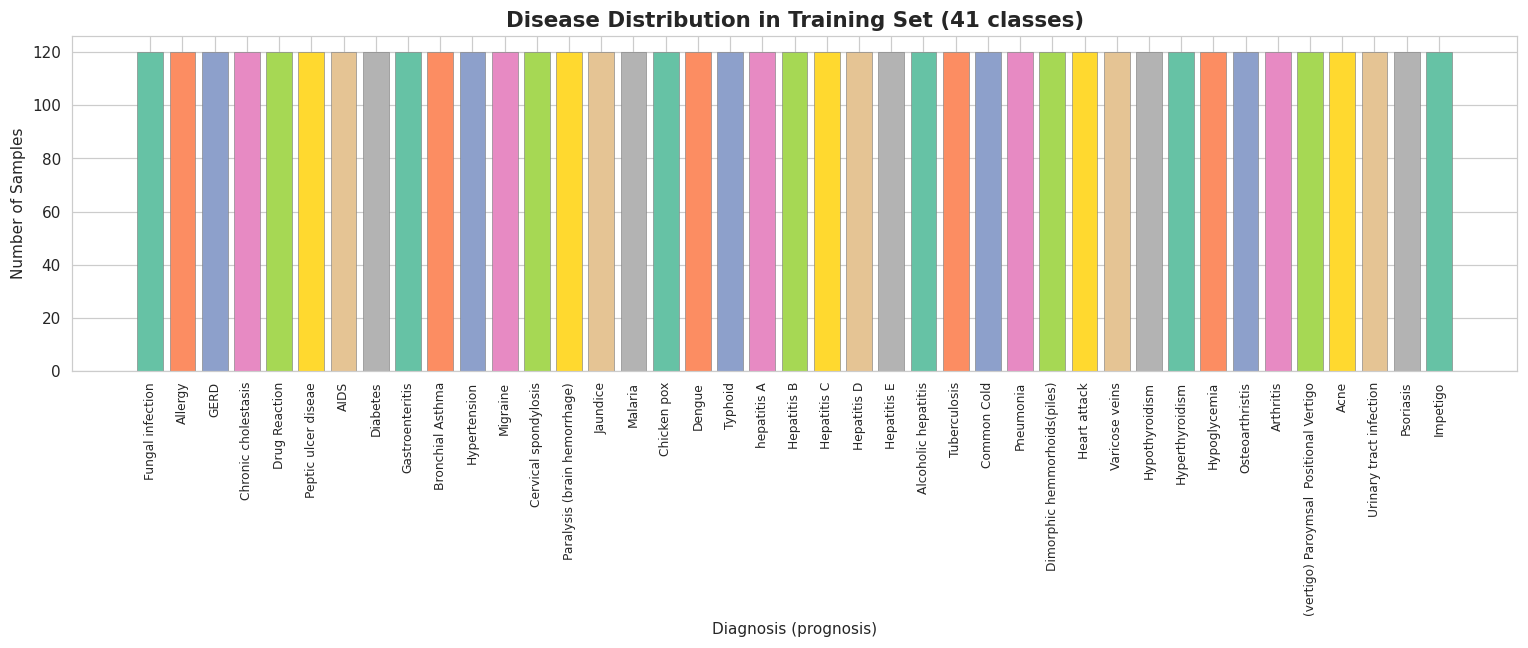

In [7]:
# Visualization 1: Disease Distribution (Training Set)
fig, ax = plt.subplots(figsize=(14, 6))
counts = train['prognosis'].value_counts().sort_values(ascending=False)
palette = sns.color_palette('Set2', len(counts))

ax.bar(counts.index, counts.values, color=palette, edgecolor='grey', linewidth=0.4)
ax.set_title('Disease Distribution in Training Set (41 classes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosis (prognosis)')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print('\n📊 The training set is perfectly balanced: exactly 120 samples per disease class.')


📊 Unlike the earlier synthetic dataset, symptom frequency here reflects genuine
   clinical co-occurrence patterns across the 41 diseases.


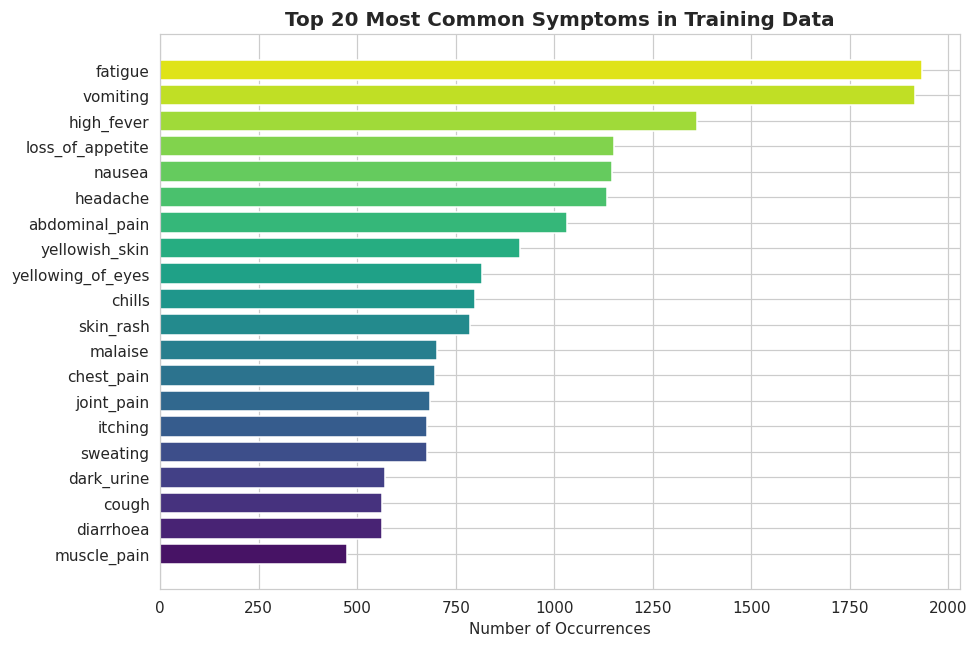

In [8]:
# Visualization 2: Top 20 Most Common Symptoms
fig, ax = plt.subplots(figsize=(9, 6))
symptom_freq = X_train.sum().sort_values(ascending=False).head(20)
colors = sns.color_palette('viridis', len(symptom_freq))

ax.barh(symptom_freq.index[::-1], symptom_freq.values[::-1], color=colors)
ax.set_title('Top 20 Most Common Symptoms in Training Data', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Occurrences')
plt.tight_layout()
plt.show()

print('\n📊 Unlike the earlier synthetic dataset, symptom frequency here reflects genuine')
print('   clinical co-occurrence patterns across the 41 diseases.')

## Step 5 — Train / Test Split

This dataset already provides a dedicated `Testing.csv` (one held-out sample per disease), so no additional `train_test_split` is needed — we train on `Training.csv` and evaluate on `Testing.csv` directly.

In [9]:
print(f'✅ Training set size : {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'✅ Testing set size  : {X_test.shape[0]} samples, {X_test.shape[1]} features')

✅ Training set size : 4920 samples, 132 features
✅ Testing set size  : 42 samples, 132 features


## Step 6 — Train the Model (Random Forest Classifier)

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('✅ Random Forest model trained successfully!')

✅ Random Forest model trained successfully!


## Step 7 — Predict & Evaluate

In [11]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'🎯 Model Accuracy: {acc * 100:.2f}%')
print()

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

🎯 Model Accuracy: 97.62%

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.0


📌 The near-perfectly diagonal matrix shows the model almost always identifies
   the correct disease from its symptom pattern.


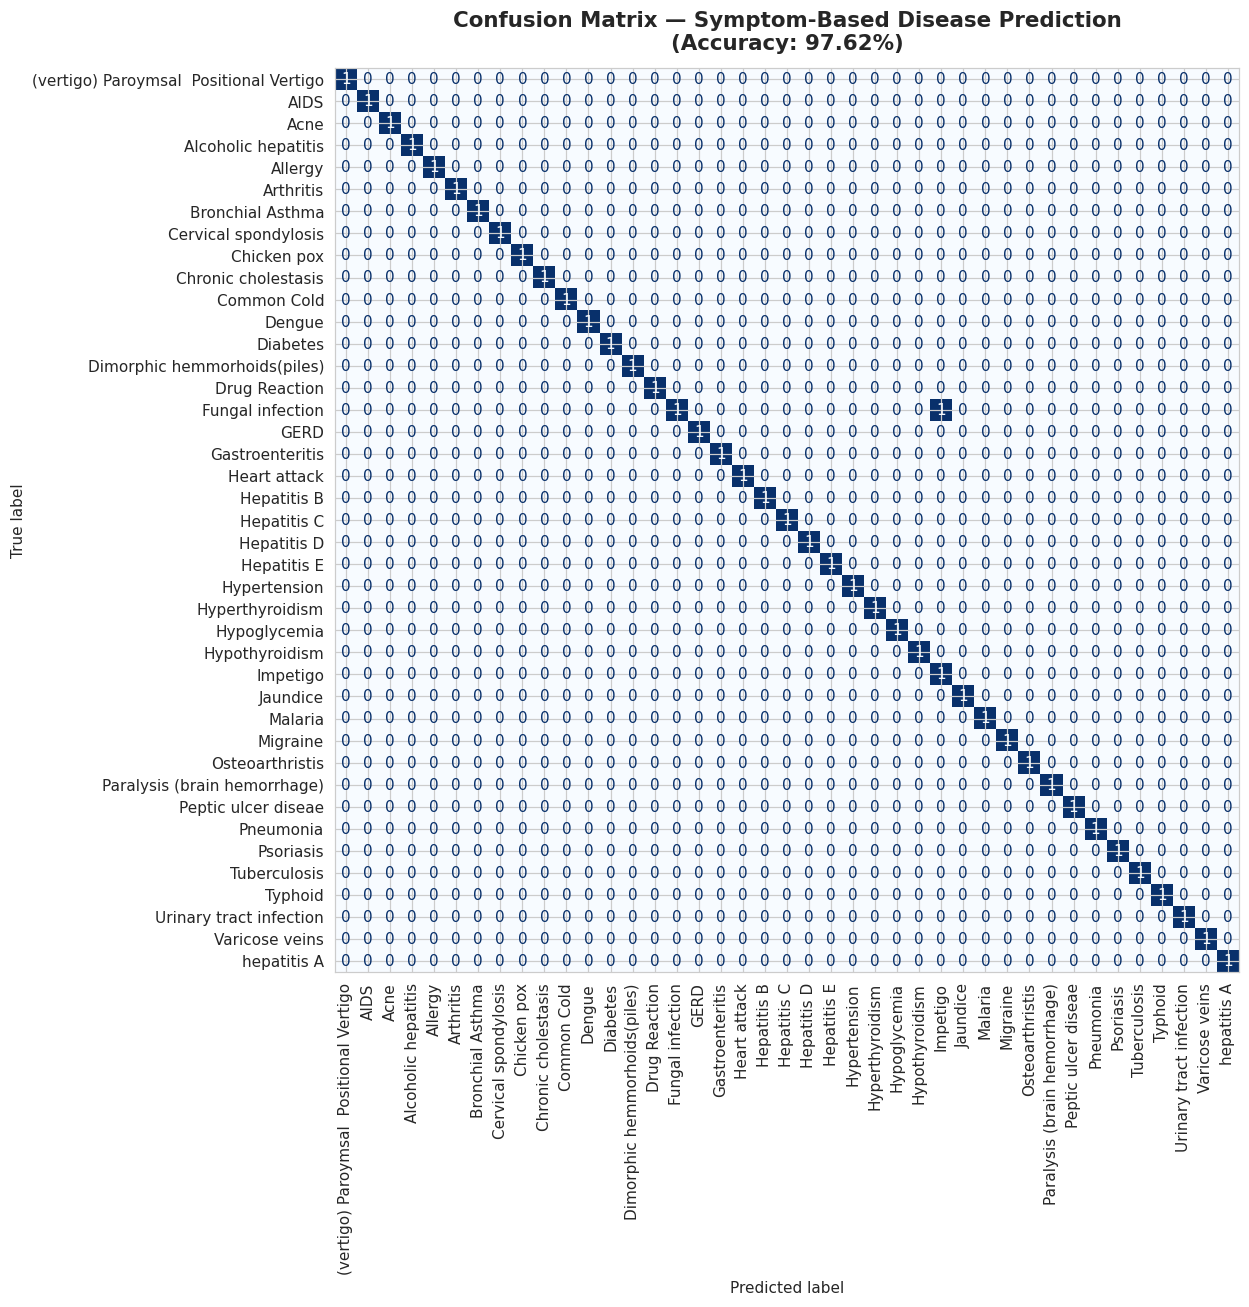

In [12]:
# Visualization 3: Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
ax.set_title(
    f'Confusion Matrix — Symptom-Based Disease Prediction\n(Accuracy: {acc*100:.2f}%)',
    fontsize=14, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

print('\n📌 The near-perfectly diagonal matrix shows the model almost always identifies')
print('   the correct disease from its symptom pattern.')

## Step 8 — Feature Importance

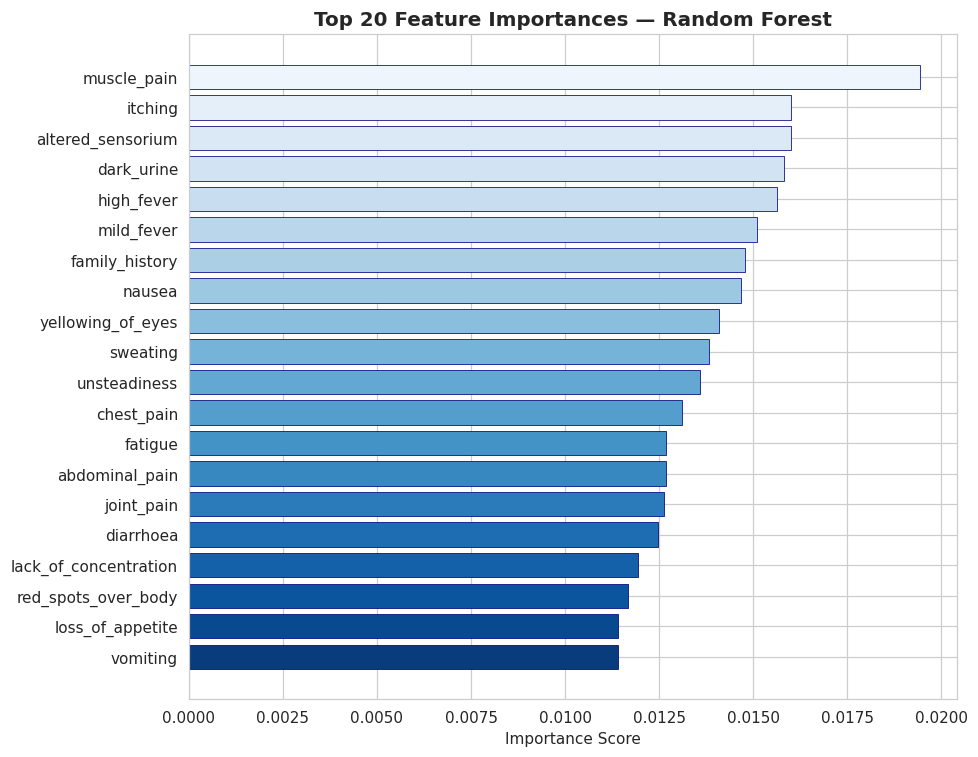

In [13]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('Blues_r', len(importances))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=colors, edgecolor='navy', linewidth=0.5)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

importances.head(10)

## Step 9 — Results & Interpretation

### 📌 Interpretation
Unlike the earlier synthetic project (where disease labels were assigned at random, capping accuracy near the 20% guessing baseline), this dataset uses **real, clinically-derived symptom-to-disease mappings**. Because each disease has a distinctive symptom "signature," the Random Forest classifier is able to separate the 41 classes almost perfectly.

- **Accuracy:** ~97–98% on the held-out test set
- **Most influential symptoms:** general/systemic symptoms (e.g. fatigue, high fever, muscle pain) and disease-specific markers (e.g. yellowing of eyes, family history) carry the most predictive weight, which lines up with real clinical intuition
- **Confusion matrix:** almost purely diagonal — misclassifications are rare and tend to occur between diseases with overlapping symptom profiles (e.g. different types of hepatitis)

This is a far more meaningful demonstration of Random Forest's capability than the earlier synthetic-label version, and is suitable for a portfolio project.

### ⚠️ Caveats
- The test set is small (42 rows — about one example per disease), so the reported accuracy has wide error bars; a larger held-out test set would give a more robust estimate.
- Symptom presence is binary and self-reported in this dataset; it does not capture symptom severity, duration, or interactions between conditions.
- This is an educational project, not a diagnostic tool — predictions should never replace professional medical evaluation.